# ¿El cambio climático ya subió la malaria infantil en África?

Durante décadas la respuesta fue una pelea de expertos sin datos suficientes para zanjarla. Un siglo de encuestas clínicas acaba de contestar — y la respuesta no es sí, ni es no.

:::{image} figuras/pixabot.png
:alt: Mascota Pixabot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Carlson et al. (2026), *The past and future impact of climate change on childhood malaria in Africa*, **Nature**
**DOI:** [10.1038/s41586-026-10840-w](https://doi.org/10.1038/s41586-026-10840-w)
**Datos:** tablas de resultados del [repositorio de código de los autores](https://github.com/cjcarlson/falciparum)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-31-clima-malaria-infantil-africa/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/dhW36wYgP1g)

## De qué estamos hablando

África subsahariana concentra cerca del 95% de la carga mundial de malaria, y en esa región el 80% de las muertes son de niños menores de 5 años. Por eso la pregunta importa tanto: si el calentamiento movió esa carga, movió una de las cargas de enfermedad más grandes del planeta.

El equipo juntó **50.425 encuestas de prevalencia** hechas entre **1900 y 2016** y las condensó en **9.875 valores mensuales** a nivel de región administrativa. El indicador es el PfPR 2-10: qué porcentaje de los niños de 2 a 10 años carga el parásito *Plasmodium falciparum* en la sangre.

Sobre esos datos corrieron un modelo econométrico que separa el efecto de la temperatura y la lluvia extrema del efecto de todo lo demás — mosquiteros, medicamentos, guerras, urbanización — y luego preguntaron qué habría pasado sin el calentamiento causado por humanos.

> **Unidad de aquí en adelante:** casos por cada 1.000 niños. Es la misma unidad del resumen del paper, y equivale a puntos porcentuales de prevalencia multiplicados por 10.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
T_OPTIMA = 24.9              # Temperatura óptima de transmisión del paper (°C)
T_OPTIMA_CI = (21.0, 27.1)   # Intervalo de confianza del 95% del óptimo
FUENTE = ('Fuente: Carlson et al. (2026), Nature  |  '
          'Datos: tablas de resultados del repositorio de los autores')
COLOR_DATOS = '#2563EB'      # Azul CaM — dato principal
COLOR_ALERTA = '#DC2626'     # Rojo — más malaria / referencia
COLOR_BAJA = '#059669'       # Verde — menos malaria
COLOR_REFERENCIA = '#D97706' # Ámbar — escenario intermedio
COLOR_CONTEXTO = '#999999'   # Gris — no distinguible de cero

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local → respaldo en GitHub)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(BASE + '/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)


def es(x, dec=2):
    """Formato numérico español: coma decimal, punto de miles."""
    s = ('{:,.' + str(dec) + 'f}').format(x)
    return s.replace(',', '@').replace('.', ',').replace('@', '.')


# ── Carga ──────────────────────────────────────────────────────────
hist = pd.read_csv('datos/atribucion_historica.csv')
futuro = pd.read_csv('datos/proyecciones_futuro.csv')
mitig = pd.read_csv('datos/beneficio_mitigacion.csv')
robust = pd.read_csv('datos/coeficientes_robustez.csv')
sensib = pd.read_csv('datos/sensibilidad_fuente_climatica.csv')
mensual = pd.read_csv('datos/impacto_mensual.csv')
curva = pd.read_csv('datos/curva_termica.csv')

# Nombres de región en español (los CSV vienen del repo en inglés)
ES_REGION = {
    'Sub-Saharan Africa (continent-wide)': 'África subsahariana (total)',
    'Southern Africa': 'África Austral',
    'West Africa': 'África Occidental',
    'East Africa': 'África Oriental',
    'Central Africa': 'África Central',
}
for _df in (hist, futuro, mitig, mensual):
    _df['region_es'] = _df['region'].map(ES_REGION)

print('Atribución histórica :', hist.shape[0], 'regiones')
print('Proyecciones futuras :', futuro.shape[0], 'filas',
      '=', futuro.region.nunique(), 'regiones x',
      futuro.escenario.nunique(), 'escenarios x',
      futuro.periodo.nunique(), 'periodos')
print('Curva térmica        :', curva.shape[0], 'puntos entre',
      es(curva.temperatura_c.min(), 1), 'y',
      es(curva.temperatura_c.max(), 1), '°C')
print()
cont = hist[hist.region_es == 'África subsahariana (total)'].iloc[0]
print('Impacto histórico continental: ' + es(cont.efecto_por_1000) +
      ' casos por cada 1.000 niños ' +
      '(IC 95%: ' + es(cont.ci_bajo_por_1000) + ' a ' +
      es(cont.ci_alto_por_1000) + ')')

Atribución histórica : 5 regiones
Proyecciones futuras : 30 filas = 5 regiones x 3 escenarios x 2 periodos
Curva térmica        : 81 puntos entre 15,0 y 35,0 °C

Impacto histórico continental: 0,73 casos por cada 1.000 niños (IC 95%: -4,11 a 5,99)


## El mosquito tiene una temperatura favorita

Antes de mirar mapas o décadas, hay que entender una sola cosa. Aquí está.

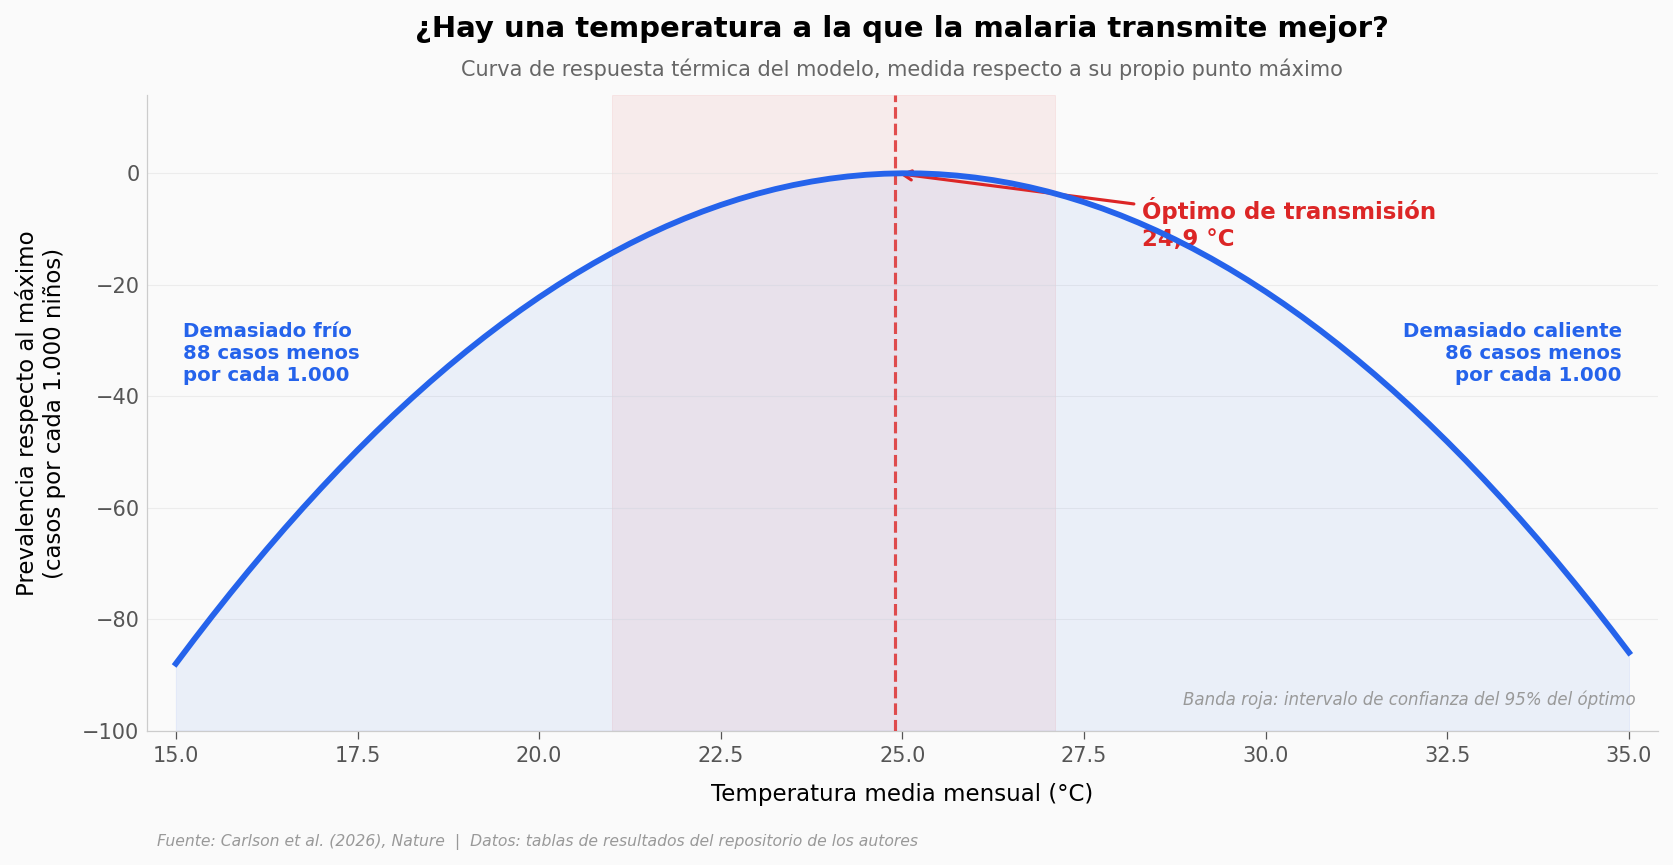

Óptimo del paper                       : 24,9 °C  (IC 95%: 21,0 a 27,1)
Máximo de la curva reconstruida        : 25,0 °C  (malla de 0,25 °C)


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x, y = curva.temperatura_c.values, curva.delta_por_1000.values
ax.plot(x, y, color=COLOR_DATOS, linewidth=2.8, zorder=6)
ax.fill_between(x, y, -100, color=COLOR_DATOS, alpha=0.07, zorder=2)

# Óptimo del paper y su intervalo de confianza
ax.axvspan(T_OPTIMA_CI[0], T_OPTIMA_CI[1], color=COLOR_ALERTA,
           alpha=0.07, zorder=1)
ax.axvline(T_OPTIMA, color=COLOR_ALERTA, linewidth=1.5,
           linestyle='--', alpha=0.8, zorder=4)

# Caída en los dos extremos, leída de los datos
caida_frio = y[0]
caida_calor = y[-1]
ax.annotate('Óptimo de transmisión\n' + es(T_OPTIMA, 1) + ' °C',
            xy=(T_OPTIMA, 0), xytext=(T_OPTIMA + 3.4, -13),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))
ax.text(15.1, -38, 'Demasiado frío\n' +
        es(abs(caida_frio), 0) + ' casos menos\npor cada 1.000',
        fontsize=9.5, color=COLOR_DATOS, fontweight='bold',
        va='bottom', ha='left')
ax.text(34.9, -38, 'Demasiado caliente\n' +
        es(abs(caida_calor), 0) + ' casos menos\npor cada 1.000',
        fontsize=9.5, color=COLOR_DATOS, fontweight='bold',
        va='bottom', ha='right')

ax.set_ylim(-100, 14)
ax.set_xlim(14.6, 35.4)
ax.set_xlabel('Temperatura media mensual (°C)', fontsize=11)
ax.set_ylabel('Prevalencia respecto al máximo\n'
              '(casos por cada 1.000 niños)', fontsize=11)
ax.set_title('¿Hay una temperatura a la que la malaria transmite mejor?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Curva de respuesta térmica del modelo, '
        'medida respecto a su propio punto máximo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.985, 0.04, 'Banda roja: intervalo de confianza del 95% del óptimo',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/curva_termica.png', dpi=200, bbox_inches='tight')
plt.show()

print('Óptimo del paper                       : ' + es(T_OPTIMA, 1) +
      ' °C  (IC 95%: ' + es(T_OPTIMA_CI[0], 1) + ' a ' +
      es(T_OPTIMA_CI[1], 1) + ')')
print('Máximo de la curva reconstruida        : ' +
      es(curva.loc[curva.delta_por_1000.idxmax(), 'temperatura_c'], 1) +
      ' °C  (malla de 0,25 °C)')

## Una loma, no una rampa

La transmisión no crece con el calor: crece hasta un punto y después se desploma. El modelo sitúa ese punto en **24,9 °C** (intervalo de confianza del 95%: 21,0 a 27,1 °C), y coincide con lo que se ve en laboratorio, donde la transmisión pica cerca de los 25 °C y se vuelve insignificante por debajo de ~16 °C o por encima de ~34 °C.

Alejarse 10 °C del óptimo — hacia arriba o hacia abajo — baja la prevalencia casi 9 puntos porcentuales, que en la unidad de este notebook son entre **86 y 88 casos menos por cada 1.000 niños**: 88 en el extremo frío (15 °C) y 86 en el caliente (35 °C), los mismos valores que rotula la gráfica de arriba.

De esa forma de loma sale todo lo demás. En la lógica del modelo, calentar un lugar que está por debajo del óptimo va con más malaria; calentar uno que ya está en el óptimo, con menos. El mismo grado de más apunta en direcciones opuestas según dónde caiga.

> **Cómo se construyó esta curva:** la dibujamos nosotros a partir de los coeficientes de temperatura, y está expresada **respecto a su propio máximo**, no en nivel absoluto. Un detalle que conviene tener a mano: el ajuste exacto de esta curva corresponde a T = 4,36 y T² = -0,087, con el vértice en 25,06 °C — y ese -0,087 **no** está en las tablas de `datos/`, que traen el coeficiente redondeado a dos decimales (-0,09). Con el valor redondeado el vértice se corre a 24,2 °C, que es el número que sale en la celda experimental del final. El modelo usa efectos fijos, que identifican diferencias pero no el nivel de base de cada lugar. Es una simplificación didáctica de la forma de la respuesta, no una predicción de prevalencia para una temperatura dada.

## Entonces, ¿qué pasó en el siglo que ya corrió?

Si el efecto del calor depende de dónde estabas parado en esa loma, el calentamiento ya ocurrido no pudo haber empujado a todas las regiones en la misma dirección. Veamos qué atribuye el modelo, región por región.

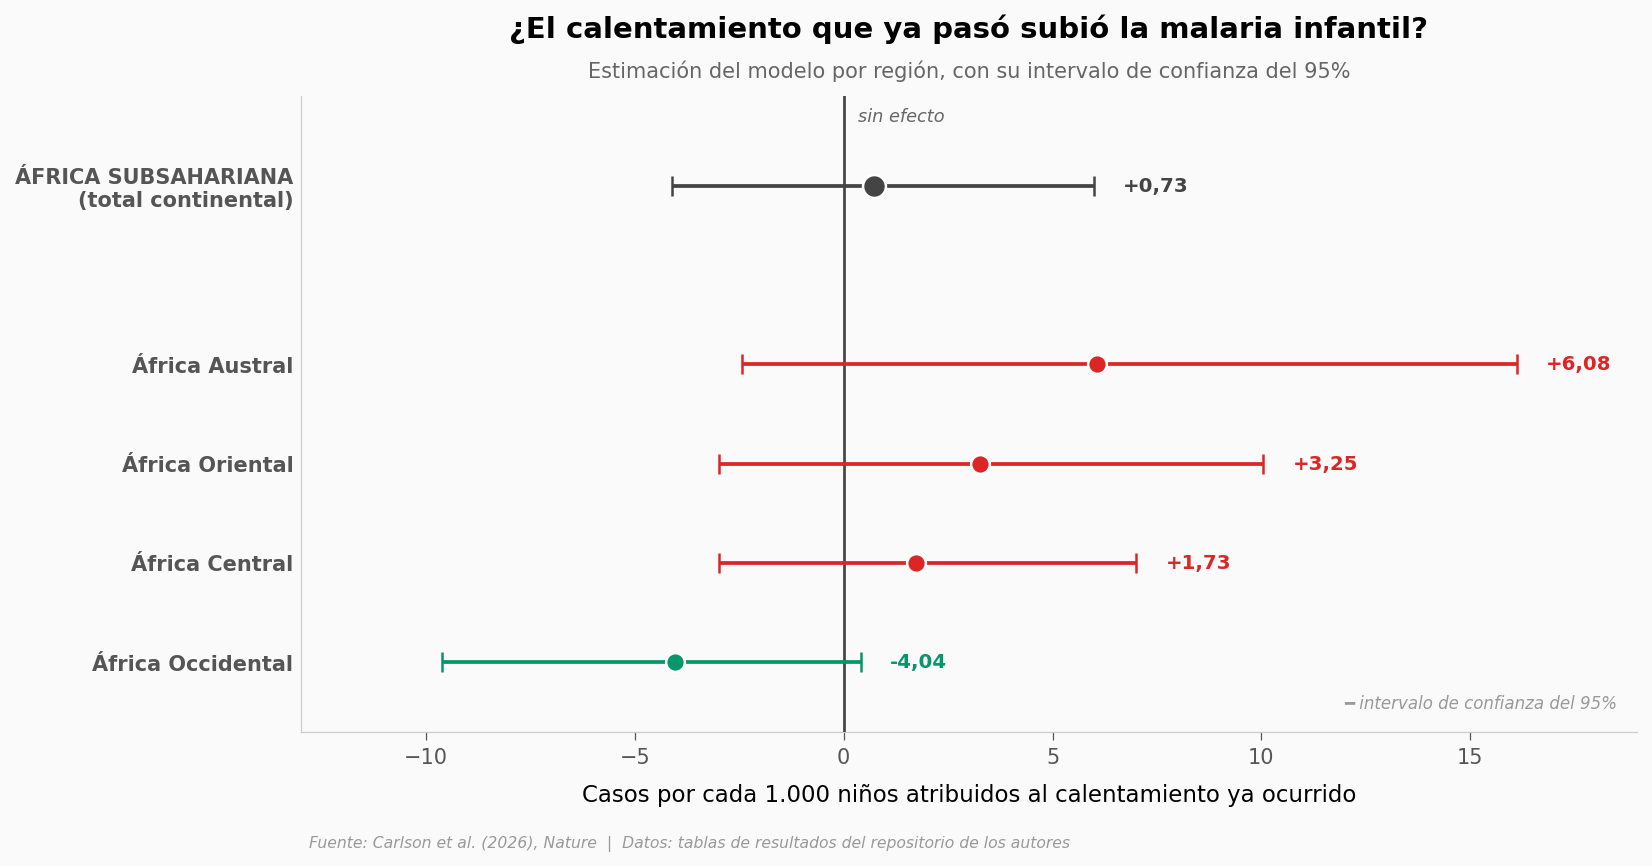

Estimaciones cuyo intervalo de confianza incluye el cero: 5 de 5


In [3]:
orden = ['África Occidental', 'África Central', 'África Oriental',
         'África Austral']
fig, ax = plt.subplots(figsize=(11.5, 5.5))

pos_map = {}
for i, reg in enumerate(orden):
    pos_map[reg] = i
pos_map['África subsahariana (total)'] = len(orden) + 0.8  # separado arriba

for _, r in hist.iterrows():
    reg = r.region_es
    ypos = pos_map[reg]
    es_total = reg.startswith('África subsahariana')
    if es_total:
        col = '#444444'
    else:
        col = COLOR_ALERTA if r.efecto_por_1000 > 0 else COLOR_BAJA
    ax.errorbar(r.efecto_por_1000, ypos,
                xerr=[[r.efecto_por_1000 - r.ci_bajo_por_1000],
                      [r.ci_alto_por_1000 - r.efecto_por_1000]],
                fmt='o', color=col, markersize=11 if es_total else 9,
                markeredgecolor='white', markeredgewidth=1.2,
                capsize=5, capthick=1.4, elinewidth=1.8, zorder=5)
    ax.text(r.ci_alto_por_1000 + 0.7, ypos,
            ('+' if r.efecto_por_1000 > 0 else '') + es(r.efecto_por_1000),
            fontsize=9.5, color=col, fontweight='bold', va='center')

ax.axvline(0, color='#444444', linewidth=1.3, zorder=3)
ax.text(0.35, len(orden) + 1.45, 'sin efecto', fontsize=8.5,
        color='#666666', style='italic')

ax.set_yticks([pos_map[r] for r in orden] +
              [pos_map['África subsahariana (total)']])
ax.set_yticklabels(orden + ['ÁFRICA SUBSAHARIANA\n(total continental)'],
                   fontsize=10, fontweight='bold')
ax.set_ylim(-0.7, len(orden) + 1.7)
ax.set_xlim(-13, 19)
ax.set_xlabel('Casos por cada 1.000 niños atribuidos al calentamiento '
              'ya ocurrido', fontsize=11)
ax.set_title('¿El calentamiento que ya pasó subió la malaria infantil?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Estimación del modelo por región, con su intervalo '
        'de confianza del 95%', transform=ax.transAxes,
        fontsize=10, color='#666666', ha='center')
ax.text(0.985, 0.03, '\u2501 intervalo de confianza del 95%',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')
ax.grid(axis='y', visible=False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/atribucion_historica.png', dpi=200, bbox_inches='tight')
plt.show()

cruza = ((hist.ci_bajo_por_1000 < 0) & (hist.ci_alto_por_1000 > 0)).sum()
print('Estimaciones cuyo intervalo de confianza incluye el cero: ' +
      str(cruza) + ' de ' + str(len(hist)))

## No subió ni bajó: se movió de sitio

Mira el patrón antes que los números. Las cuatro regiones no apuntan al mismo lado. En **África Austral** la estimación es de **+6,08 casos por cada 1.000**, en **África Oriental** de **+3,25** y en **África Central** de **+1,73**. En **África Occidental** — justo donde la carga de malaria es más alta — la estimación va al otro lado: **-4,04**.

Sumadas, esas fuerzas opuestas casi se cancelan: el total continental queda en **+0,73 casos por cada 1.000**. El paper lo redondea a 1 caso por cada 1.000.

Y ahora la parte incómoda, que es la que más se pierde cuando este resultado pasa a un titular: **los cinco intervalos de confianza cruzan el cero**, incluido el continental (-4,11 a +5,99). Ninguna de esas estimaciones es estadísticamente distinguible de "no pasó nada". Por eso el propio resumen del paper dice que las temperaturas en alza **probablemente** subieron la malaria en el este y el sur — no que la subieron. Ese "probablemente" no es adorno: es la distancia entre lo que el modelo estima y lo que puede sostener.

Lo que sí queda en pie es la forma del resultado: no es un aumento continental, es una **redistribución**. Y si eso ya pasó con el calentamiento de hasta hoy, la pregunta obvia es qué pasa si el termómetro sigue subiendo.

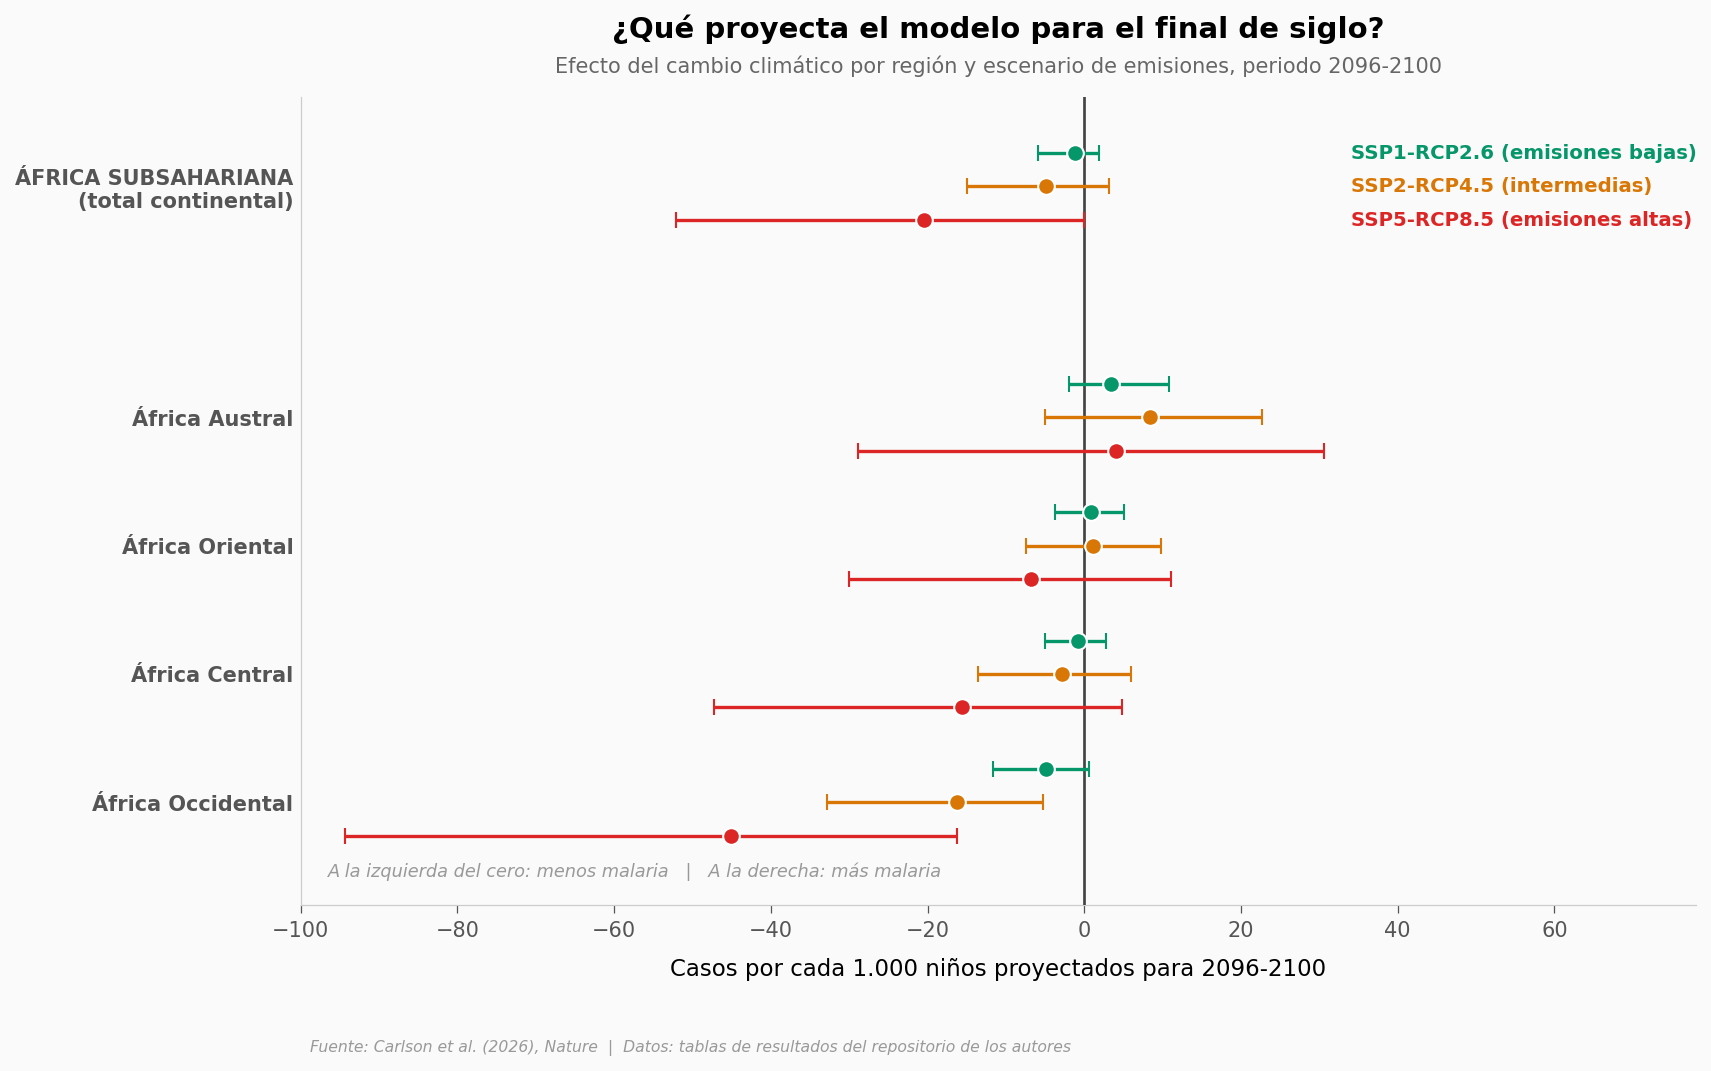

África Occidental              | SSP1-RCP2.6: -4,93  |  SSP2-RCP4.5: -16,22  |  SSP5-RCP8.5: -45,02
África Oriental                | SSP1-RCP2.6: 0,92  |  SSP2-RCP4.5: 1,11  |  SSP5-RCP8.5: -6,78
África subsahariana (total)    | SSP1-RCP2.6: -1,15  |  SSP2-RCP4.5: -4,88  |  SSP5-RCP8.5: -20,39


In [4]:
fut = futuro[futuro.periodo == '2096-2100'].copy()
escenarios = [
    ('SSP1-RCP2.6', 'emisiones bajas', COLOR_BAJA),
    ('SSP2-RCP4.5', 'intermedias', COLOR_REFERENCIA),
    ('SSP5-RCP8.5', 'emisiones altas', COLOR_ALERTA),
]
grupos = ['África Occidental', 'África Central', 'África Oriental',
          'África Austral', 'África subsahariana (total)']
offsets = [0.26, 0.0, -0.26]

fig, ax = plt.subplots(figsize=(12, 7))
for gi, reg in enumerate(grupos):
    ybase = gi + (0.8 if reg.startswith('África subsahariana') else 0.0)
    for (esc, _lab, col), off in zip(escenarios, offsets):
        r = fut[(fut.region_es == reg) & (fut.escenario == esc)].iloc[0]
        ax.errorbar(r.efecto_por_1000, ybase + off,
                    xerr=[[r.efecto_por_1000 - r.ci_bajo_por_1000],
                          [r.ci_alto_por_1000 - r.efecto_por_1000]],
                    fmt='o', color=col, markersize=8,
                    markeredgecolor='white', markeredgewidth=1.0,
                    capsize=4, capthick=1.2, elinewidth=1.6, zorder=5)

# Etiquetas de escenario en línea, sobre el grupo superior (sin caja de leyenda)
ytop = (len(grupos) - 1) + 0.8
for (esc, lab, col), off in zip(escenarios, offsets):
    ax.text(34, ytop + off, esc + ' (' + lab + ')', fontsize=9.5,
            color=col, fontweight='bold', va='center')

ax.axvline(0, color='#444444', linewidth=1.3, zorder=3)
ax.set_yticks([gi + (0.8 if g.startswith('África subsahariana') else 0.0)
               for gi, g in enumerate(grupos)])
ax.set_yticklabels([g if not g.startswith('África subsahariana')
                    else 'ÁFRICA SUBSAHARIANA\n(total continental)'
                    for g in grupos], fontsize=10, fontweight='bold')
ax.set_ylim(-0.8, len(grupos) + 0.5)
ax.set_xlim(-100, 78)
ax.set_xlabel('Casos por cada 1.000 niños proyectados para 2096-2100',
              fontsize=11)
ax.set_title('¿Qué proyecta el modelo para el final de siglo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Efecto del cambio climático por región y escenario '
        'de emisiones, periodo 2096-2100', transform=ax.transAxes,
        fontsize=10, color='#666666', ha='center')
ax.text(0.02, 0.03, 'A la izquierda del cero: menos malaria   |   '
        'A la derecha: más malaria', transform=ax.transAxes,
        fontsize=8.5, color='#999999', va='bottom', style='italic')
ax.grid(axis='y', visible=False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/proyecciones_2100.png', dpi=200, bbox_inches='tight')
plt.show()

for reg in ['África Occidental', 'África Oriental',
            'África subsahariana (total)']:
    fila = []
    for esc, _l, _c in escenarios:
        r = fut[(fut.region_es == reg) & (fut.escenario == esc)].iloc[0]
        fila.append(esc + ': ' + es(r.efecto_por_1000))
    print(reg.ljust(30) + ' | ' + '  |  '.join(fila))

## El escenario más caliente proyecta menos malaria

Mira qué pasa en **África Occidental**. Con emisiones altas (SSP5-RCP8.5), a 2096-2100, el modelo proyecta **-45,02 casos por cada 1.000 niños**. Menos malaria. Y como esa es la región con más carga del continente, arrastra el total: el continente entero cae a **-20,39 casos por cada 1.000** en ese mismo escenario y periodo.

La razón es la loma de la primera gráfica. África Occidental hoy está cerca del óptimo de transmisión; calentarla varios grados la empuja **por encima** de los 24,9 °C, hacia el lado donde el mosquito y el parásito ya no funcionan bien. El modelo no está diciendo que el calentamiento extremo sea bueno: lo único que estima es malaria. Que la transmisión caiga a esas temperaturas no dice nada sobre el resto de lo que trae un escenario de emisiones altas — nada de eso está en este modelo ni en estos datos.

Hay un detalle más que conviene no generalizar: **África Oriental cambia de signo entre escenarios**. Con emisiones intermedias (SSP2-RCP4.5) a 2096-2100 la estimación es **+1,11 casos por cada 1.000**; con emisiones altas (SSP5-RCP8.5), **-6,78**. Decir "el este empeora" sin nombrar el escenario es decir algo que los datos no sostienen.

Con todo esto sobre la mesa, la pregunta final es la única que importa: **¿cuáles de estos números se distinguen realmente de cero?**

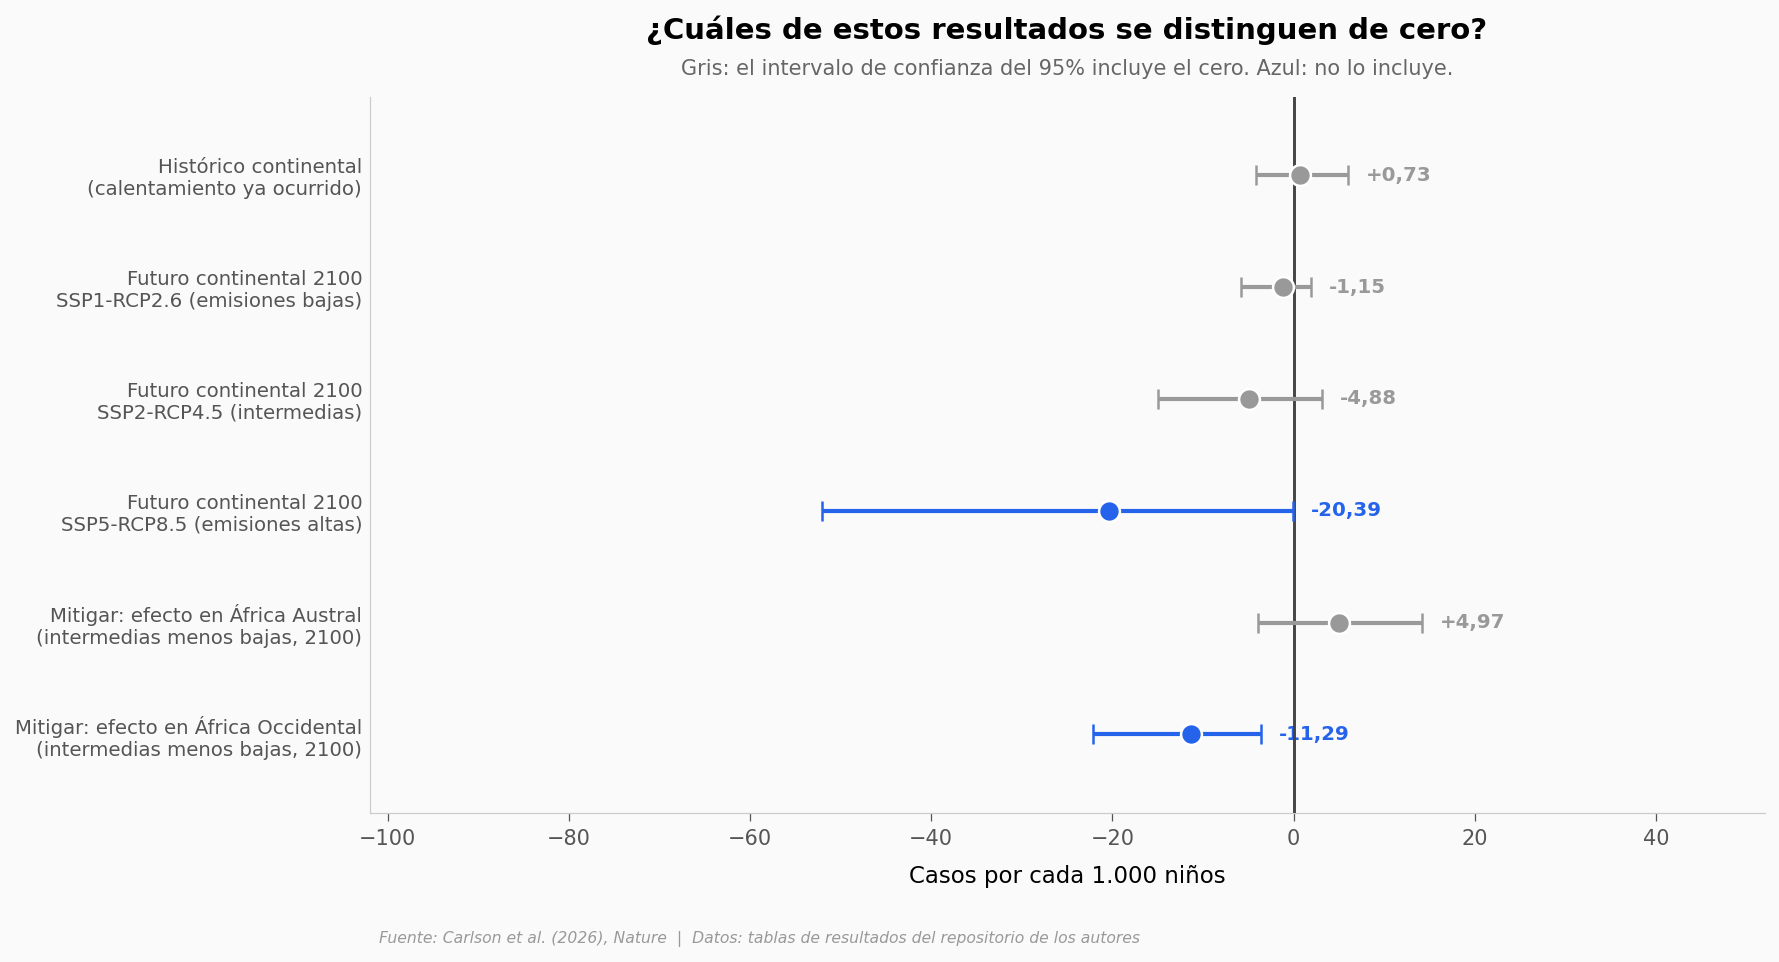

Titulares cuyo intervalo de confianza incluye el cero: 4 de 6


In [5]:
# Síntesis: los titulares del paper, cada uno con su intervalo de confianza
cont_hist = hist[hist.region_es == 'África subsahariana (total)'].iloc[0]
mit = mitig[mitig.periodo == '2096-2100']
mit_aus = mit[mit.region_es == 'África Austral'].iloc[0]
mit_occ = mit[mit.region_es == 'África Occidental'].iloc[0]


def fila_fut(esc):
    r = fut[(fut.region_es == 'África subsahariana (total)') &
            (fut.escenario == esc)].iloc[0]
    return r.efecto_por_1000, r.ci_bajo_por_1000, r.ci_alto_por_1000


titulares = [
    ('Mitigar: efecto en África Occidental\n(intermedias menos bajas, 2100)',
     mit_occ.efecto_por_1000, mit_occ.ci_bajo_por_1000,
     mit_occ.ci_alto_por_1000),
    ('Mitigar: efecto en África Austral\n(intermedias menos bajas, 2100)',
     mit_aus.efecto_por_1000, mit_aus.ci_bajo_por_1000,
     mit_aus.ci_alto_por_1000),
    ('Futuro continental 2100\nSSP5-RCP8.5 (emisiones altas)',) +
    fila_fut('SSP5-RCP8.5'),
    ('Futuro continental 2100\nSSP2-RCP4.5 (intermedias)',) +
    fila_fut('SSP2-RCP4.5'),
    ('Futuro continental 2100\nSSP1-RCP2.6 (emisiones bajas)',) +
    fila_fut('SSP1-RCP2.6'),
    ('Histórico continental\n(calentamiento ya ocurrido)',
     cont_hist.efecto_por_1000, cont_hist.ci_bajo_por_1000,
     cont_hist.ci_alto_por_1000),
]

fig, ax = plt.subplots(figsize=(12, 6.2))
n_cruza = 0
for i, (lab, val, lo, hi) in enumerate(titulares):
    cruza_cero = lo < 0 < hi
    n_cruza += int(cruza_cero)
    col = COLOR_CONTEXTO if cruza_cero else COLOR_DATOS
    ax.errorbar(val, i, xerr=[[val - lo], [hi - val]], fmt='o', color=col,
                markersize=10, markeredgecolor='white', markeredgewidth=1.2,
                capsize=5, capthick=1.4, elinewidth=2.0, zorder=5)
    ax.text(hi + 2.0, i, ('+' if val > 0 else '') + es(val),
            fontsize=9.5, color=col, fontweight='bold', va='center')

ax.axvline(0, color='#444444', linewidth=1.4, zorder=3)
ax.set_yticks(range(len(titulares)))
ax.set_yticklabels([t[0] for t in titulares], fontsize=9.5)
ax.set_ylim(-0.7, len(titulares) - 0.3)
ax.set_xlim(-102, 52)
ax.set_xlabel('Casos por cada 1.000 niños', fontsize=11)
ax.set_title('¿Cuáles de estos resultados se distinguen de cero?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Gris: el intervalo de confianza del 95% incluye el cero. '
        'Azul: no lo incluye.', transform=ax.transAxes,
        fontsize=10, color='#666666', ha='center')
ax.grid(axis='y', visible=False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sintesis_incertidumbre.png', dpi=200,
            bbox_inches='tight')
plt.show()

print('Titulares cuyo intervalo de confianza incluye el cero: ' +
      str(n_cruza) + ' de ' + str(len(titulares)))

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Existe una temperatura óptima de transmisión cerca de los 25 °C | ✅ | El modelo la sitúa en 24,9 °C (intervalo de confianza del 95%: 21,0 a 27,1 °C). El máximo de la curva que reconstruimos cae en 25,0 °C, pero rehaciendo el vértice con los coeficientes redondeados de `datos/` da 24,2 °C: los tres valores caben holgadamente dentro del intervalo del paper, y la coincidencia de 0,1 °C depende de cuántos decimales se usen, no es una verificación independiente. Los experimentos de laboratorio dan el mismo pico. |
| El calentamiento ya ocurrido subió la malaria en el este y el sur de África | ⚠️ | Las estimaciones van en esa dirección (África Austral +6,08 y África Oriental +3,25 casos por cada 1.000), pero **ambos intervalos de confianza cruzan el cero**. El resumen del paper lo enmarca como algo que *probablemente* ocurrió, no como un hecho establecido. |
| El impacto histórico neto sobre el continente es cercano a cero | ✅ | +0,73 casos por cada 1.000 (intervalo de confianza del 95%: -4,11 a +5,99). El paper lo redondea a 1 caso por cada 1.000. Es una redistribución entre regiones, no un aumento continental. |
| Con emisiones altas el modelo proyecta menos malaria a fin de siglo | ✅ | -20,39 casos por cada 1.000 para el continente en 2096-2100 bajo SSP5-RCP8.5 (intervalo: -52,10 a -0,04). Es el único resultado continental cuyo intervalo no incluye el cero — por 0,04 casos. El resumen del paper reporta ese mismo límite ya redondeado a 0, así que es significancia de puro margen. Lo empuja África Occidental (-45,02 en ese mismo escenario y periodo), que se calienta por encima del óptimo. |
| Limitar el calentamiento evitaría casos en África Austral | ⚠️ | Pasar de emisiones intermedias (SSP2-RCP4.5) a bajas (SSP1-RCP2.6) deja +4,97 casos por cada 1.000 evitables en África Austral en 2096-2100, pero su intervalo va de -3,94 a +14,14. En África Occidental, misma comparación y mismo periodo, el signo se invierte: -11,29 (intervalo -22,18 a -3,64), el único de los cuatro resultados de mitigación de 2096-2100 que no cruza el cero. |
| El efecto de la temperatura aguanta cambios en cómo se agrupa la incertidumbre entre países y años (*clustering*) | ✅ | El coeficiente de temperatura es 4,36 en los 6 niveles de agrupamiento probados; el error estándar va de 1,09 a 1,84 (una diferencia de 1,7 veces). El valor t más bajo es 2,37. |
| El modelo captura la mayor parte de lo que mueve la malaria | ❌ | R² = 0,53 (R² ajustado = 0,49) sobre n = 9.875 — cifras reportadas en el paper; no están en las tablas de `datos/` y este notebook no las recalcula. El 47% de la variación queda fuera: mosquiteros, medicamentos, conflicto armado, urbanización. |

> **Limitaciones:**
>
> - **Diseño observacional.** El modelo *atribuye* estadísticamente, comparando lo ocurrido con un mundo simulado sin calentamiento causado por humanos. No hay experimento ni asignación aleatoria: no se puede leer como causalidad demostrada.
> - **Los intervalos de confianza mandan.** Ninguna de las 5 estimaciones históricas se distingue de cero, y solo 2 de los 6 titulares de la última gráfica lo hacen. Un número puntual sin su intervalo dice mucho más de lo que estos datos permiten decir.
> - **La curva térmica es una construcción nuestra.** La derivamos de los coeficientes publicados y está expresada respecto a su propio máximo, no en nivel absoluto. Es una simplificación didáctica de la forma de la respuesta, no la curva formal del paper.
> - **Depende de qué datos climáticos se usen.** Cuando los autores rehacen el modelo con ERA5 en vez de CRU, el coeficiente de temperatura pasa de 4,36 a 2,83 (un 35% menos). Pero esos coeficientes traen errores estándar de 1,52 y 1,25, y sus intervalos de confianza del 95% (1,4 a 7,3 y 0,4 a 5,3) se solapan casi por completo: la caída va en esa dirección, no es distinguible del ruido. El óptimo baja unos 0,6 °C en el cálculo de la celda experimental, pero como esos coeficientes vienen redondeados a dos decimales, esa diferencia de vértices es la cantidad peor identificada del notebook. La forma del resultado aguanta; la magnitud, menos.
> - **El subgrupo de alta elevación no está aquí.** El resumen del paper reporta 5 casos por cada 1.000 evitables en el África Oriental por encima de 1 km de altitud. Ese corte no aparece en las tablas que usamos, así que la cifra es del paper, no de este notebook.
> - **Los datos no son el repositorio oficial completo.** El conjunto depositado en Zenodo pesa 11,8 GB y no lo descargamos. Los números salen de las tablas de resultados publicadas en el repositorio de código de los autores, que reproducen las cifras del resumen del paper.

## Ahora tú

**1. ¿Cambia la historia si el clima se mide con otro termómetro?**
El modelo principal usa CRU. El paper también lo corre con ERA5. Reconstruye la curva térmica con los coeficientes de cada fuente y compara dónde queda el óptimo.
*Pista:* `sensib[sensib.fuente_climatica == 'ERA5']` — la curva es `coef_T · T + coef_T² · T²`, y el vértice está en `-coef_T / (2 · coef_T²)`.

**2. ¿En qué mes del año pega más fuerte el efecto?**
El impacto no está repartido parejo por el calendario. Mira el pico mensual por región y compáralo con el promedio anual.
*Pista:* `mensual[['region_es', 'mes_pico', 'pico_por_1000', 'anual_por_1000']]`.

**3. ¿Cuánto del resultado continental depende de África Occidental?**
El total del continente se mueve mucho por una sola región. Compara las estimaciones regionales de 2096-2100 con y sin ella.
*Pista:* filtra `fut` por `region_es != 'África Occidental'` y mira qué queda.

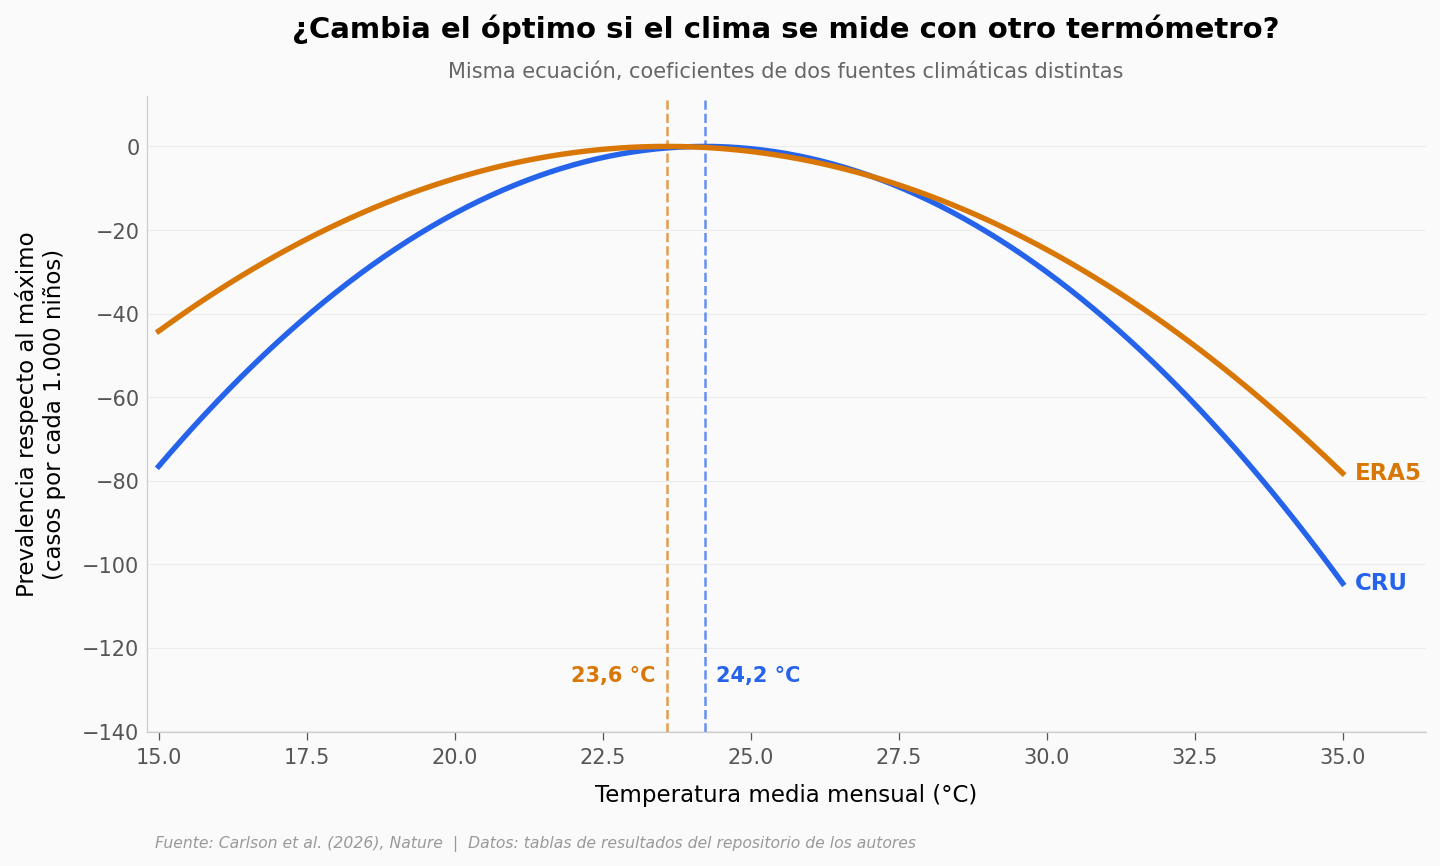

CRU    | coef T = 4,36 | coef T² = -0,09 | óptimo = 24,2 °C
ERA5   | coef T = 2,83 | coef T² = -0,06 | óptimo = 23,6 °C

Diferencia de óptimo entre fuentes: 0,6 °C
El coeficiente de temperatura cae un 35% con ERA5.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: el óptimo de transmisión, según la fuente de datos climáticos.
# Ojo con la comparación: los coeficientes de esta tabla vienen redondeados a
# dos decimales, así que el óptimo que sale aquí no coincide ni con los 24,9 °C
# del paper ni con el máximo de la curva de más arriba. Lo comparable es la
# DIFERENCIA entre las dos fuentes, no el valor absoluto de cada una.

fig, ax = plt.subplots(figsize=(11, 5.5))
temps = np.linspace(15, 35, 201)
colores = {'CRU (completo)': COLOR_DATOS, 'ERA5': COLOR_REFERENCIA}
resumen = []

for fuente, col in colores.items():
    sub = sensib[sensib.fuente_climatica == fuente]
    b1 = sub[sub.variable == 'Temperatura media (°C)'].coeficiente.iloc[0]
    b2 = sub[sub.variable == 'Temperatura media² (°C²)'].coeficiente.iloc[0]
    vertice = -b1 / (2 * b2)
    # Respecto al máximo y en casos por cada 1.000 (x10 desde puntos porcentuales)
    y = ((b1 * temps + b2 * temps ** 2) -
         (b1 * vertice + b2 * vertice ** 2)) * 10
    ax.plot(temps, y, color=col, linewidth=2.6, zorder=5)
    ax.axvline(vertice, color=col, linestyle='--', linewidth=1.2, alpha=0.7)
    # ERA5 a la izquierda de su línea, CRU a la derecha: los vértices
    # distan solo 0,6 °C y las etiquetas se pisarían.
    lado = 'right' if fuente == 'ERA5' else 'left'
    dx = -0.2 if lado == 'right' else 0.2
    ax.text(vertice + dx, -128, es(vertice, 1) + ' °C',
            color=col, fontsize=10, fontweight='bold', ha=lado)
    etiqueta = 'CRU' if fuente.startswith('CRU') else 'ERA5'
    ax.text(35.2, y[-1], etiqueta, color=col, fontsize=11,
            fontweight='bold', va='center')
    resumen.append((etiqueta, b1, b2, vertice))

ax.set_ylim(-140, 12)
ax.set_xlim(14.8, 36.4)
ax.set_xlabel('Temperatura media mensual (°C)', fontsize=11)
ax.set_ylabel('Prevalencia respecto al máximo\n'
              '(casos por cada 1.000 niños)', fontsize=11)
ax.set_title('¿Cambia el óptimo si el clima se mide con otro termómetro?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Misma ecuación, coeficientes de dos fuentes '
        'climáticas distintas', transform=ax.transAxes,
        fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/experimento_era5.png', dpi=200, bbox_inches='tight')
plt.show()

for etq, b1, b2, v in resumen:
    print(etq.ljust(6) + ' | coef T = ' + es(b1) + ' | coef T² = ' +
          es(b2) + ' | óptimo = ' + es(v, 1) + ' °C')
print()
print('Diferencia de óptimo entre fuentes: ' +
      es(abs(resumen[0][3] - resumen[1][3]), 1) + ' °C')
print('El coeficiente de temperatura cae un ' +
      es((1 - resumen[1][1] / resumen[0][1]) * 100, 0) + '% con ERA5.')

---

## Fuentes

**Paper**: [The past and future impact of climate change on childhood malaria in Africa](https://doi.org/10.1038/s41586-026-10840-w)  
*Nature, 2026-07-29* · acceso abierto (CC-BY 4.0)

**Dataset canónico**: [Replication code and result tables for 'The past and future impact of climate change on childhood malaria in Africa'](https://github.com/cjcarlson/falciparum)  
*GitHub — cjcarlson/falciparum* — tablas de resultados publicadas por los autores; de aquí salen los CSV de `datos/`.

**Referencias citadas**: [Zenodo](https://doi.org/10.5281/zenodo.20399793) · [Nature](https://doi.org/10.1038/nature24059) · [Scientific Data](https://doi.org/10.1038/s41597-020-0453-3)

*18 afirmaciones del notebook verificadas contra estas fuentes*

---

**Licencia del paper:** CC-BY 4.0 · **Este notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)

*Reproducible de punta a punta: los CSV de `datos/` vienen de las tablas de resultados publicadas por los autores.*